In [10]:
# --- Project path setup (run first) ---
import sys
from pathlib import Path

ROOT = Path.cwd()
if (ROOT / "config.py").exists():
    PROJECT_ROOT = ROOT
elif (ROOT.parent / "config.py").exists():
    PROJECT_ROOT = ROOT.parent
else:
    PROJECT_ROOT = ROOT

sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from itertools import combinations, product

from config import *
from Data.raw_data_loader import load_ibit_with_mining_cost

from Backtest.engine import run_backtest
from Backtest.metrics import build_summary_table

from Models.amma import amma_signal
from Models.zscore import zscore_signal
from Models.trend import trend_signal
from Models.ou import ou_signal
from Models.mining import mining_signal




In [11]:
# --- Load ETHA data (CSV) ---
from pathlib import Path

def load_etha_only(etha_csv_path: str | Path) -> pd.DataFrame:
    p = Path(etha_csv_path)
    if not p.exists():
        raise FileNotFoundError(
            f"ETHA CSV not found: {p}\n"
            f"Set ETHA_CSV_PATH to the correct location. "
            f"Recommended: put ETHA.csv under PROJECT_ROOT/Data/."
        )

    d = pd.read_csv(p).copy()
    d.columns = [str(c).strip() for c in d.columns]

    # Try common column names
    date_candidates = ["Date", "date", "End", "Timestamp"]
    close_candidates = ["Close", "close", "Adj Close", "AdjClose", "Price", "price"]

    date_col = next((c for c in date_candidates if c in d.columns), None)
    close_col = next((c for c in close_candidates if c in d.columns), None)

    if date_col is None or close_col is None:
        raise KeyError(
            "Could not infer date/close columns from ETHA CSV.\n"
            f"Columns found: {list(d.columns)}\n"
            f"Expected one of date={date_candidates} and close={close_candidates}."
        )

    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d[close_col] = pd.to_numeric(d[close_col], errors="coerce")

    d = d.dropna(subset=[date_col, close_col]).sort_values(date_col).set_index(date_col)

    out = pd.DataFrame({"close": d[close_col].astype(float)})
    out = out[~out.index.duplicated(keep="last")].sort_index()
    return out


# Set this path once:
ETHA_CSV_PATH = (PROJECT_ROOT / "Data" / "ETHA.csv")

df = load_etha_only(ETHA_CSV_PATH)
df.head()


,close
End,
2016-01-12,1.06040
2016-01-13,1.14873
2016-01-14,1.12304
2016-01-15,1.18905
2016-01-16,1.21428


In [12]:
PRICE_COL = "ETHA_close"
df = df.rename(columns={"close": PRICE_COL}).copy()
df = df[~df.index.duplicated(keep="last")].sort_index()

print(df.head())
print(df.tail())
print("rows:", len(df), "start:", df.index.min(), "end:", df.index.max())

            ETHA_close
End                   
2016-01-12     1.06040
2016-01-13     1.14873
2016-01-14     1.12304
2016-01-15     1.18905
2016-01-16     1.21428
            ETHA_close
End                   
2026-02-06   1824.6902
2026-02-07   2061.3085
2026-02-08   2090.9076
2026-02-09   2096.1317
2026-02-10   2105.0785
rows: 3683 start: 2016-01-12 00:00:00 end: 2026-02-10 00:00:00


In [13]:
# --- Backtest wrapper (no leverage; engine applies lag/clip) ---

def infer_trading_days_per_year(idx: pd.DatetimeIndex) -> int:
    # If data is daily-ish, use 252. If it's weekly-ish, use 52.
    # This only affects the *manual* Sharpe calc later (the summary table uses your metrics module).
    if len(idx) < 10:
        return 252
    dt = pd.Series(idx).diff().dt.days.dropna()
    med = float(dt.median())
    return 252 if med <= 3.5 else 52

DAYS_PER_YEAR = infer_trading_days_per_year(df.index)

def bt(position: pd.Series, name: str):
    position = position.reindex(df.index).fillna(0.0).clip(0.0, 1.0)
    return run_backtest(
        df=df,
        price_col=PRICE_COL,
        position=position,
        fee_bps=0.0,
        slippage_bps=0.0,
        annual_borrow_rate=0.0,
        long_only=True,
        leverage_cap=1.0,
    )


In [14]:
def pos_buyhold(d: pd.DataFrame) -> pd.Series:
    return pd.Series(1.0, index=d.index)

def pos_amma(d: pd.DataFrame) -> pd.Series:
    return amma_signal(d, price_column=PRICE_COL).clip(0.0, 1.0)

def pos_trend(d: pd.DataFrame) -> pd.Series:
    return trend_signal(
        d,
        price_column=PRICE_COL,
        mode="faber_10m",
        ma_months=10,
        exposure_on=1.0,
        exposure_off=0.0,   # set to 0.25 if you want less cash drag
    ).clip(0.0, 1.0)

def pos_zscore(d: pd.DataFrame) -> pd.Series:
    return zscore_signal(
        price_series=d[PRICE_COL],
        window=90,
        entry_z=1.75,
        exit_z=0.25,
        use_trend_gate=True,
        gate_ma_months=10,
        allow_in_risk_on=True,
        allow_in_risk_off=False,
        detrend_ema_span=60,
        min_hold_days=5,
        cooldown_days=3,
        mode="derisk_overbought",
    ).clip(0.0, 1.0)

def pos_ou(d: pd.DataFrame) -> pd.Series:
    # OU is an overlay: returns 0..overlay_max (unshifted)
    return ou_signal(
        price_series=d[PRICE_COL],
        detrend_span=60,
        z_window=90,
        entry_z=1.0,
        exit_z=0.25,
        overlay_max=0.40,
        use_trend_gate=True,
        gate_ma_months=10,
        vol_window=20,
        vol_cap=0.035,
        min_hold_days=5,
        cooldown_days=3,
    ).clip(0.0, 1.0)

BASELINES = {"buyhold": pos_buyhold, "amma": pos_amma}
CORE_MODELS = {"trend": pos_trend, "zscore": pos_zscore, "ou": pos_ou}

In [15]:
results = {}

results["buyhold"] = bt(BASELINES["buyhold"](df), "buyhold")
results["amma"] = bt(BASELINES["amma"](df), "amma")

for k, fn in CORE_MODELS.items():
    results[k] = bt(fn(df), k)

table_single = build_summary_table({
    k: {"returns": v["net_returns"], "position": v["position"]}
    for k, v in results.items()
}).sort_values("Sharpe", ascending=False)

display(table_single)

,Sharpe,Sortino,CAGR,MaxDD,Calmar,AnnualReturn,AnnualVol,Observations,AnnualTurnover
Strategy,,,,,,,,,
amma,1.387841,1.857091,1.038050,-0.669155,1.551284,0.935994,0.674425,3683,15.608879
buyhold,1.256575,1.848718,1.122389,-0.942142,1.191316,1.228307,0.977504,3683,0.099104
trend,0.873561,0.927879,0.448513,-0.932537,0.480960,0.632130,0.723625,3683,2.180288
zscore,0.403613,0.365676,0.061388,-0.894819,0.068604,0.242890,0.601790,3683,4.360576
ou,-0.213973,-0.080211,-0.018664,-0.218532,-0.085405,-0.016027,0.074902,3683,2.061363


In [16]:
def _month_end_close(price: pd.Series) -> pd.Series:
    try:
        return price.resample("ME").last()
    except ValueError:
        return price.resample("M").last()

def _risk_on_gate_from_monthly_ma(price: pd.Series, ma_months: int = 10) -> pd.Series:
    monthly = _month_end_close(price)
    ma = monthly.rolling(int(ma_months), min_periods=int(ma_months)).mean()
    risk_on_m = (monthly > ma).astype(float)
    return risk_on_m.reindex(price.index, method="ffill").fillna(0.0)

# Build model positions once
core_pos = {k: CORE_MODELS[k](df).clip(0.0, 1.0) for k in CORE_MODELS}
base_pos = {k: BASELINES[k](df).clip(0.0, 1.0) for k in BASELINES}

# FIX: define signals so the combo function can use it
signals = core_pos

def overlay_combo_position_eth(
    w,
    base=None,
    risk_on_floor=1.0,
    risk_off_floor=0.0,
    smooth_span=3,
    crash_floor=0.0,
    crash_vol_window=20,
    crash_vol_cap=0.06,
    crash_dd_window=63,
    crash_dd_cap=0.25,
):
    """
    Build a long-only position that can go to cash in crash regimes (e.g. 2022).
    Outputs UN-SHIFTED position in [0,1].
    """
    idx = df.index

    # base exposure: default fully invested
    if base is None:
        base = pd.Series(1.0, index=idx)
    else:
        base = base.reindex(idx).fillna(1.0)

    # Core model positions (already in [0,1], unshifted)
    p_ou = signals["ou"].reindex(idx).fillna(0.0).clip(0.0, 1.0)
    p_z  = signals["zscore"].reindex(idx).fillna(0.0).clip(0.0, 1.0)
    p_tr = signals["trend"].reindex(idx).fillna(0.0).clip(0.0, 1.0)

    w_ou, w_z, w_tr = w

    # Regime proxy: trend
    risk_on = (p_tr > 0.5).astype(float)

    # Floors by regime
    floor = risk_on_floor * risk_on + risk_off_floor * (1.0 - risk_on)

    # Derisk when zscore/trend are low
    derisk = (w_z * (1.0 - p_z)) + (w_tr * (1.0 - p_tr))

    # OU overlay adds exposure
    rerisk = w_ou * p_ou

    pos = base - derisk + rerisk
    pos = np.maximum(pos, floor)

    # Crash filter: go to cash (or crash_floor)
    price = df[PRICE_COL].astype(float)
    ret = price.pct_change()

    vol = ret.rolling(crash_vol_window, min_periods=max(10, crash_vol_window // 2)).std()
    too_volatile = (vol > crash_vol_cap).fillna(False)

    roll_peak = price.rolling(crash_dd_window, min_periods=max(20, crash_dd_window // 2)).max()
    dd = (price / roll_peak) - 1.0
    too_deep = (dd < -crash_dd_cap).fillna(False)

    crash = (too_volatile | too_deep)
    pos = pos.where(~crash, other=crash_floor)

    # Smooth
    ss = int(max(1, smooth_span))
    if ss > 1:
        pos = pos.ewm(span=ss, adjust=False, min_periods=ss).mean()

    return pd.Series(pos, index=idx).clip(0.0, 1.0)

def weight_grid(step=0.1, require_nonzero=True):
    vals = np.arange(0.0, 1.0 + 1e-12, step)
    for w_ou in vals:
        for w_z in vals:
            for w_t in vals:
                if require_nonzero and (w_ou < step or w_z < step or w_t < step):
                    continue
                # cap total de-risk weight to avoid too much cash drag
                if (w_z + w_t) > 1.0 + 1e-12:
                    continue
                yield np.array([w_ou, w_z, w_t], dtype=float)

In [17]:
def max_drawdown(equity: pd.Series) -> float:
    eq = equity.dropna().astype(float)
    if eq.empty:
        return np.nan
    peak = eq.cummax()
    dd = (eq / peak) - 1.0
    return float(dd.min())

# Buy&Hold drawdown benchmark
bh_dd = max_drawdown(results["buyhold"]["net_equity"])
print("Buy&Hold MaxDD:", bh_dd)

best = None
best_any = None  # fallback if constraints filter everything out

# Search:
# - weights: [w_ou, w_zscore, w_trend]
risk_on_floors = [0.90, 0.95, 1.00]
risk_off_floors = [0.00]
smooth_spans = [1, 3, 5]

# Drawdown constraint:
# Require at least X% smaller drawdown magnitude vs buy&hold.
# Example: dd_frac = 0.85 means "15% less drawdown than buy&hold"
dd_frac = 1.00

bh_dd_abs = abs(bh_dd) if np.isfinite(bh_dd) else np.nan

for w in weight_grid(step=0.1, require_nonzero=True):
    for rof in risk_on_floors:
        for rff in risk_off_floors:
            for ss in smooth_spans:

                pos = overlay_combo_position_eth(
    w,
    base=None,
    risk_on_floor=rof,
    risk_off_floor=rff,
    smooth_span=ss,
)
                res = bt(pos, "grand_combo")

                res = bt(pos, "grand_combo")

                r = res["net_returns"].dropna()
                sd = r.std(ddof=1)
                sharpe = (r.mean() * DAYS_PER_YEAR) / (sd * np.sqrt(DAYS_PER_YEAR)) if sd > 0 else np.nan

                dd = max_drawdown(res["net_equity"])
                dd_abs = abs(dd) if np.isfinite(dd) else np.nan

                # Score: Sharpe with a small drawdown penalty
                score = sharpe - 0.10 * dd_abs if np.isfinite(sharpe) and np.isfinite(dd_abs) else np.nan

                candidate = {
                    "weights": w,
                    "risk_on_floor": rof,
                    "risk_off_floor": rff,
                    "smooth_span": ss,
                    "sharpe": float(sharpe) if np.isfinite(sharpe) else np.nan,
                    "maxdd": float(dd) if np.isfinite(dd) else np.nan,
                    "score": float(score) if np.isfinite(score) else np.nan,
                    "result": res,
                }

                # Always track best overall (even if it fails drawdown constraint)
                if np.isfinite(candidate["score"]) and (best_any is None or candidate["score"] > best_any["score"]):
                    best_any = candidate

                # Apply drawdown constraint (only if both are finite)
                if np.isfinite(bh_dd_abs) and np.isfinite(dd_abs):
                    if dd_abs > dd_frac * bh_dd_abs:
                        continue

                # Best among feasible candidates
                if np.isfinite(candidate["score"]) and (best is None or candidate["score"] > best["score"]):
                    best = candidate

print("Best combo:")

# Fallback if nothing passed the constraint
if best is None:
    print("No combo met the drawdown constraint. Showing best Sharpe/score overall instead.")
    best = best_any

if best is None:
    raise RuntimeError("Search produced no valid results (check data / signals for NaNs).")

print("  weights [w_ou, w_zscore, w_trend]:", best["weights"])
print(
    "  risk_on_floor:", best["risk_on_floor"],
    "risk_off_floor:", best["risk_off_floor"],
    "smooth_span:", best["smooth_span"],
)
print("  Sharpe:", best["sharpe"], "MaxDD:", best["maxdd"])

results["grand_combo"] = best["result"]

Buy&Hold MaxDD: -0.9421422078796475
Best combo:
  weights [w_ou, w_zscore, w_trend]: [0.1 0.1 0.1]
  risk_on_floor: 1.0 risk_off_floor: 0.0 smooth_span: 3
  Sharpe: 0.9410833010890437 MaxDD: -0.6451815560637658


,Sharpe,Sortino,CAGR,MaxDD,Calmar,AnnualReturn,AnnualVol,Observations,AnnualTurnover
Strategy,,,,,,,,,
amma,1.387841,1.857091,1.038050,-0.669155,1.551284,0.935994,0.674425,3683,15.608879
buyhold,1.256575,1.848718,1.122389,-0.942142,1.191316,1.228307,0.977504,3683,0.099104
grand_combo,1.132594,1.470516,0.599804,-0.645182,0.929667,0.616516,0.544340,3683,9.741377
trend,0.873561,0.927879,0.448513,-0.932537,0.480960,0.632130,0.723625,3683,2.180288
zscore,0.403613,0.365676,0.061388,-0.894819,0.068604,0.242890,0.601790,3683,4.360576
ou,-0.213973,-0.080211,-0.018664,-0.218532,-0.085405,-0.016027,0.074902,3683,2.061363


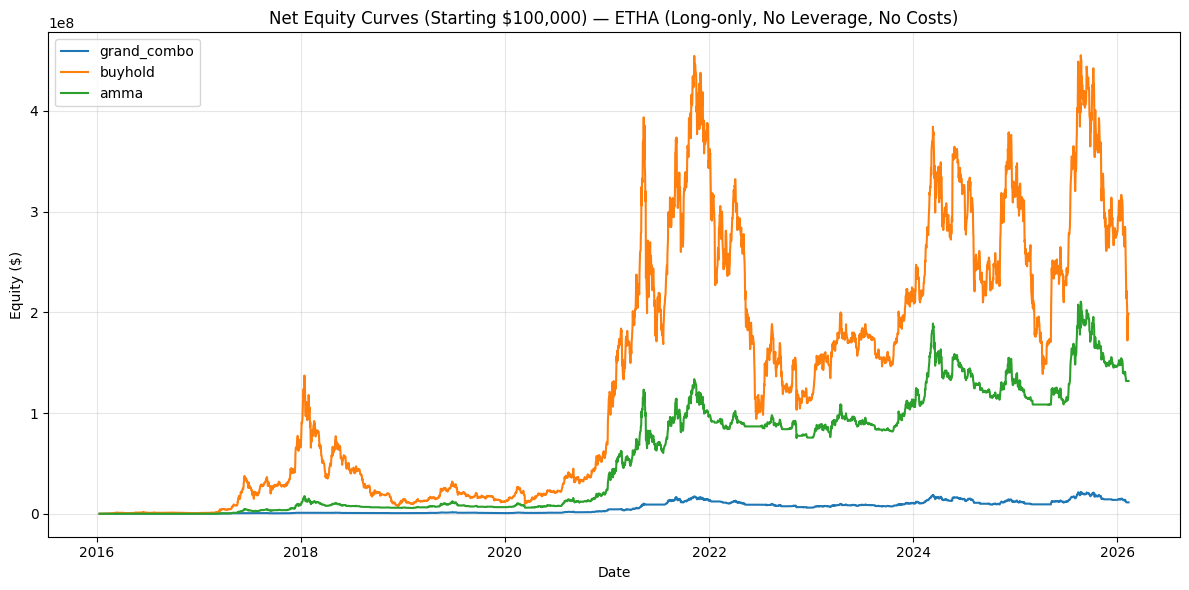

In [18]:
INITIAL_CAPITAL = 100_000
focus = ["grand_combo", "buyhold", "amma"]

table_final = build_summary_table({
    k: {"returns": v["net_returns"], "position": v["position"]}
    for k, v in results.items()
}).sort_values("Sharpe", ascending=False)

display(table_final)

plt.figure(figsize=(12, 6))
for name in focus:
    eq = INITIAL_CAPITAL * results[name]["net_equity"]
    plt.plot(eq.index, eq.values, label=name)

plt.title("Net Equity Curves (Starting $100,000) — ETHA (Long-only, No Leverage, No Costs)")
plt.xlabel("Date")
plt.ylabel("Equity ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Best no-OU weights [w_zscore, w_trend]: (0.1, 0.1)
Sharpe: 1.0194030598941062


,Sharpe,Sortino,CAGR,MaxDD,Calmar,AnnualReturn,AnnualVol,Observations,AnnualTurnover
Strategy,,,,,,,,,
amma,1.387841,1.857091,1.038050,-0.669155,1.551284,0.935994,0.674425,3683,15.608879
buyhold,1.256575,1.848718,1.122389,-0.942142,1.191316,1.228307,0.977504,3683,0.099104
grand_combo_no_ou,1.226852,1.786230,0.997252,-0.915199,1.089657,1.075389,0.876544,3683,0.701520
trend,0.873561,0.927879,0.448513,-0.932537,0.480960,0.632130,0.723625,3683,2.180288
zscore,0.403613,0.365676,0.061388,-0.894819,0.068604,0.242890,0.601790,3683,4.360576


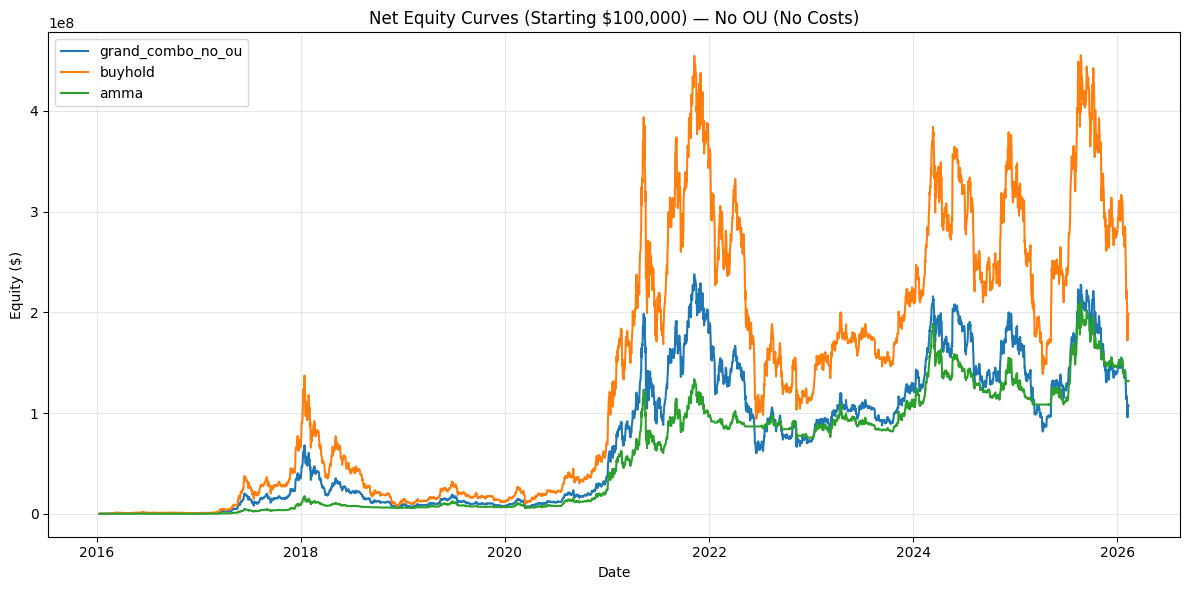

In [19]:
# --- No-OU experiment: trend + zscore only ---

# 1) Run baselines + single models (no OU)
results_no_ou = {}

results_no_ou["buyhold"] = bt(BASELINES["buyhold"](df), "buyhold")
results_no_ou["amma"] = bt(BASELINES["amma"](df), "amma")
results_no_ou["trend"] = bt(pos_trend(df), "trend")
results_no_ou["zscore"] = bt(pos_zscore(df), "zscore")

# 2) Cache positions
trend_p = pos_trend(df).reindex(df.index).fillna(0.0).clip(0.0, 1.0)
zscore_p = pos_zscore(df).reindex(df.index).fillna(0.0).clip(0.0, 1.0)
base = pd.Series(1.0, index=df.index)

# 3) Monthly risk-on floor helper (same logic as before)
def _month_end_close(price: pd.Series) -> pd.Series:
    try:
        return price.resample("ME").last()
    except ValueError:
        return price.resample("M").last()

def _risk_on_gate_from_monthly_ma(price: pd.Series, ma_months: int = 10) -> pd.Series:
    monthly = _month_end_close(price)
    ma = monthly.rolling(int(ma_months), min_periods=int(ma_months)).mean()
    risk_on_m = (monthly > ma).astype(float)
    return risk_on_m.reindex(price.index, method="ffill").fillna(0.0)

risk_on = _risk_on_gate_from_monthly_ma(df[PRICE_COL].astype(float), ma_months=10)

# 4) Search best weights (w_z, w_t) with controlled cash drag
def combo_pos_no_ou(w_z: float, w_t: float, risk_on_floor=0.85, risk_off_floor=0.35, smooth_span=5) -> pd.Series:
    derisk = w_z * (1.0 - zscore_p) + w_t * (1.0 - trend_p)
    pos = (base - derisk).clip(0.0, 1.0)

    floor = pd.Series(float(risk_off_floor), index=df.index)
    floor = floor.where(risk_on <= 0.5, other=float(risk_on_floor))
    pos = pd.Series(np.maximum(pos.values, floor.values), index=df.index).clip(0.0, 1.0)

    if smooth_span > 1:
        pos = pos.ewm(span=int(smooth_span), adjust=False).mean().clip(0.0, 1.0)

    return pos

best = None
step = 0.1
vals = np.arange(0.0, 1.0 + 1e-12, step)

for w_z in vals:
    for w_t in vals:
        if w_z < step or w_t < step:  # non-zero
            continue
        if (w_z + w_t) > 1.0 + 1e-12:
            continue

        pos = combo_pos_no_ou(w_z, w_t, risk_on_floor=0.85, risk_off_floor=0.35, smooth_span=5)
        res = bt(pos, "grand_combo_no_ou")

        r = res["net_returns"].dropna()
        sd = r.std(ddof=1)
        sharpe = (r.mean() * DAYS_PER_YEAR) / (sd * np.sqrt(DAYS_PER_YEAR)) if sd > 0 else np.nan

        if np.isfinite(sharpe) and ((best is None) or (sharpe > best["sharpe"])):
            best = {"weights": (float(w_z), float(w_t)), "sharpe": float(sharpe), "result": res}

print("Best no-OU weights [w_zscore, w_trend]:", best["weights"])
print("Sharpe:", best["sharpe"])

results_no_ou["grand_combo_no_ou"] = best["result"]

# 5) Summary + $100k plot
table_no_ou = build_summary_table({
    k: {"returns": v["net_returns"], "position": v["position"]}
    for k, v in results_no_ou.items()
}).sort_values("Sharpe", ascending=False)

display(table_no_ou)

INITIAL_CAPITAL = 100_000
plt.figure(figsize=(12, 6))
for name in ["grand_combo_no_ou", "buyhold", "amma"]:
    eq = INITIAL_CAPITAL * results_no_ou[name]["net_equity"]
    plt.plot(eq.index, eq.values, label=name)
plt.title("Net Equity Curves (Starting $100,000) — No OU (No Costs)")
plt.xlabel("Date")
plt.ylabel("Equity ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()